# Assignment 8: Data Visualization II
## Statistical Data Visualization using Seaborn

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement

To perform Exploratory Data Analysis (EDA) using Seaborn: distribution plot (histplot with KDE), box plot, violin plot, pair plot, heatmap for correlation, count plot, bar plot, joint plot, and regression plot (lmplot). Interpret the visualizations and derive insights.

## Theory

**Seaborn** is built on Matplotlib but provides a higher-level interface specifically designed for statistical visualization. Key advantages:
- Direct integration with Pandas DataFrames (pass column names as strings)
- Beautiful default styles
- Statistical plots built-in (no manual calculation needed)
- Automatic handling of categorical grouping and confidence intervals

**Plot Types:**
| Plot | Purpose |
|------|--------|
| histplot + KDE | Distribution shape of one variable |
| Box plot | Compare distributions + detect outliers |
| Violin plot | Full distribution shape across categories |
| Pair plot | All pairwise feature relationships |
| Heatmap | Color-coded matrix (correlation) |
| Count/Bar plot | Frequency or average by category |
| Joint plot | 2D relationship + marginal distributions |
| lmplot | Scatter + fitted regression line |

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully!')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Libraries imported successfully!


In [2]:
# Step 2: Load Datasets
df_iris = pd.read_csv('datasets/iris.csv')
df_tips = pd.read_csv('datasets/tips.csv')
df_penguins = pd.read_csv('datasets/penguins.csv').dropna()

print(f'Iris: {df_iris.shape}')
print(f'Tips: {df_tips.shape}')
print(f'Penguins: {df_penguins.shape}')
print(f'\nPenguins columns: {df_penguins.columns.tolist()}')
print(f'\nPenguins species:\n{df_penguins["species"].value_counts()}')

Iris: (150, 5)
Tips: (244, 7)
Penguins: (333, 7)

Penguins columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Penguins species:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


KeyError: 'sepal_length'

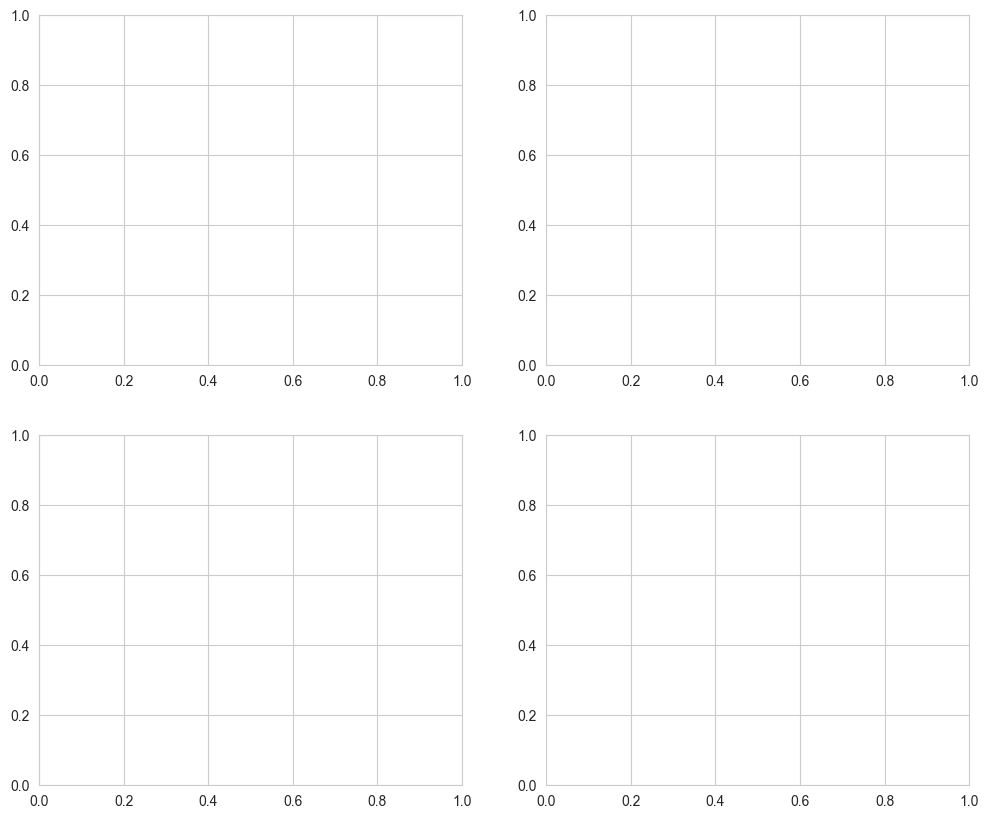

In [3]:
# Step 3: Distribution Plot — Histogram with KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, feat in zip(axes.flat, features):
    for species in df_iris['species'].unique():
        subset = df_iris[df_iris['species'] == species][feat]
        sns.histplot(subset, kde=True, ax=ax, label=species, alpha=0.4, bins=15)
    ax.set_title(f'Distribution of {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

plt.suptitle('Iris Feature Distributions by Species (Histogram + KDE)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Step 4: Box Plot — Outlier Detection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot of total_bill by day
sns.boxplot(data=df_tips, x='day', y='total_bill', hue='time', ax=axes[0],
            palette='Set2')
axes[0].set_title('Total Bill Distribution by Day and Meal Time', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Bill ($)')

# Box plot of tip by day
sns.boxplot(data=df_tips, x='day', y='tip', hue='sex', ax=axes[1], palette='Set1')
axes[1].set_title('Tip Distribution by Day and Gender', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Violin Plot — Full Distribution Shape
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot — Iris petal length by species
sns.violinplot(data=df_iris, x='species', y='petal_length', ax=axes[0],
              palette='Pastel2', inner='quartile')
axes[0].set_title('Petal Length Distribution by Species (Violin Plot)', fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Petal Length (cm)')

# Violin plot — penguins bill length by species
sns.violinplot(data=df_penguins, x='species', y='bill_length_mm', hue='sex',
              ax=axes[1], palette='Set2', split=False)
axes[1].set_title('Penguin Bill Length by Species and Sex', fontweight='bold')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Bill Length (mm)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Pair Plot — All Pairwise Relationships
print('Creating pair plot — this may take a moment...')
sns.pairplot(df_iris, hue='species', diag_kind='kde',
            plot_kws={'alpha': 0.6}, palette='Set2')
plt.suptitle('Iris Pair Plot — All Feature Combinations', fontsize=14, y=1.02)
plt.show()

In [ ]:
# Step 7: Heatmap — Correlation Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Iris correlation
iris_num = df_iris.select_dtypes(include=[np.number])
corr_iris = iris_num.corr()
sns.heatmap(corr_iris, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Iris Feature Correlation Heatmap', fontweight='bold')

# Penguins correlation
peng_num = df_penguins.select_dtypes(include=[np.number])
corr_peng = peng_num.corr()
sns.heatmap(corr_peng, annot=True, cmap='YlOrRd', fmt='.2f',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Penguins Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Step 8: Count Plot and Bar Plot for Categorical Data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Count plot — tips by day
sns.countplot(data=df_tips, x='day', hue='time', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Count of Transactions by Day and Meal', fontweight='bold')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Count')

# Count plot — penguins species
sns.countplot(data=df_penguins, x='species', hue='sex', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Penguin Count by Species and Sex', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)

# Bar plot — average tip by day and sex
sns.barplot(data=df_tips, x='day', y='tip', hue='sex', ax=axes[1, 0],
           palette='Set1', ci='sd')
axes[1, 0].set_title('Average Tip by Day and Gender', fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Tip ($)')

# Bar plot — average total_bill by day and smoker
sns.barplot(data=df_tips, x='day', y='total_bill', hue='smoker', ax=axes[1, 1],
           palette='Set2', ci='sd')
axes[1, 1].set_title('Average Bill by Day and Smoker Status', fontweight='bold')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Average Bill ($)')

plt.tight_layout()
plt.show()

In [ ]:
# Step 9: Joint Plot — Scatter + Marginal Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# We'll use sns.jointplot via its own figure or replicate with subplots
# Since jointplot creates its own figure, let's show two separately
print('Joint Plot 1: Total Bill vs Tip')
jp1 = sns.jointplot(data=df_tips, x='total_bill', y='tip', kind='reg',
                    height=6, color='steelblue')
jp1.fig.suptitle('Total Bill vs Tip (with Regression)', y=1.02)
plt.show()

print('Joint Plot 2: Sepal Length vs Petal Length by Species')
jp2 = sns.jointplot(data=df_iris, x='sepal_length', y='petal_length',
                    hue='species', kind='scatter', height=6, palette='Set2')
jp2.fig.suptitle('Sepal Length vs Petal Length by Species', y=1.02)
plt.show()

In [ ]:
# Step 10: Regression Plot (lmplot) — Linear Relationship by Group
print('Regression plot: Tip vs Total Bill by Time and Smoker')
lm = sns.lmplot(data=df_tips, x='total_bill', y='tip', col='time',
               hue='smoker', height=5, aspect=1, ci=95)
lm.fig.suptitle('Tip vs Total Bill: Regression by Meal Time and Smoker', y=1.02)
plt.show()

In [ ]:
# Step 11: Insights and Summary
print('=' * 60)
print('KEY INSIGHTS FROM SEABORN EDA')
print('=' * 60)
print()
print('Iris Dataset:')
print('  - Setosa has distinctly smaller petal dimensions')
print('  - Petal length and petal width are highly correlated (r > 0.96)')
print('  - Sepal width has low correlation with other features')
print()
print('Tips Dataset:')
print('  - Saturday has the highest transaction volume')
print('  - Dinner bills and tips are larger than Lunch')
print('  - Positive linear relationship between total bill and tip')
print('  - Smokers tend to tip slightly more on average')
print()
print('Penguins Dataset:')
print('  - Gentoo penguins have the largest bill length')
print('  - Clear size differences between male and female penguins')
print('  - Bill dimensions and body mass are positively correlated')

## Dataset Description

- **Iris:** 150 flowers, 4 features, 3 species
- **Tips:** 244 restaurant bills with tip amounts and metadata
- **Penguins:** 333 penguins with bill dimensions, flipper, body mass, species, sex

## Conclusion

Comprehensive Exploratory Data Analysis performed using Seaborn. All required plot types were created: histograms with KDE showing feature distributions by species, box plots revealing outliers and distribution differences across categories, violin plots showing full distribution shapes, pair plot for all pairwise feature relationships, heatmaps for correlation visualization, count/bar plots for categorical data summary, joint plots combining scatter and marginal distributions, and lmplot showing regression lines by group. Each visualization type serves a distinct analytical purpose in the EDA workflow.